In [9]:
import networkx as nx
import matplotlib.pyplot as plt

arquivo = "entrada.txt"

In [10]:
def ler_casos(arquivo):
    with open(arquivo, encoding="utf-8") as arquivo_entrada:
        linhas = [linha.split() for linha in arquivo_entrada if linha.strip()]

    casos = []
    indice = 0

    while indice < len(linhas):
        numero_ilhas, numero_pontes, numero_sedes = map(int, linhas[indice])
        indice += 1

        pontes = []
        for _ in range(numero_pontes):
            origem, destino, peso = map(int, linhas[indice])
            pontes.append((origem, destino, peso))
            indice += 1

        sedes = []
        for _ in range(numero_sedes):
            sede, deposito = map(int, linhas[indice])
            sedes.append((sede, deposito))
            indice += 1

        casos.append({
            "numero_ilhas": numero_ilhas,
            "pontes": pontes,
            "sedes": sedes,
        })

    return casos

In [11]:
def criar_grafo(caso):
    grafo = nx.Graph()
    grafo.add_nodes_from(range(1, caso["numero_ilhas"] + 1))
    grafo.add_weighted_edges_from(caso["pontes"], weight="weight")
    return grafo

casos = ler_casos(arquivo)
grafo = criar_grafo(casos[0])

In [12]:
print("Ilhas:", list(grafo.nodes))
print("Pontes:", list(grafo.edges(data="weight")))
print("Consultas sede-depósito:", casos[0]["sedes"])

Ilhas: [1, 2, 3, 4]
Pontes: [(1, 2, 9), (1, 3, 0), (2, 3, 8), (2, 4, 7), (3, 4, 4)]
Consultas sede-depósito: [(1, 4), (2, 1), (3, 1), (4, 3)]


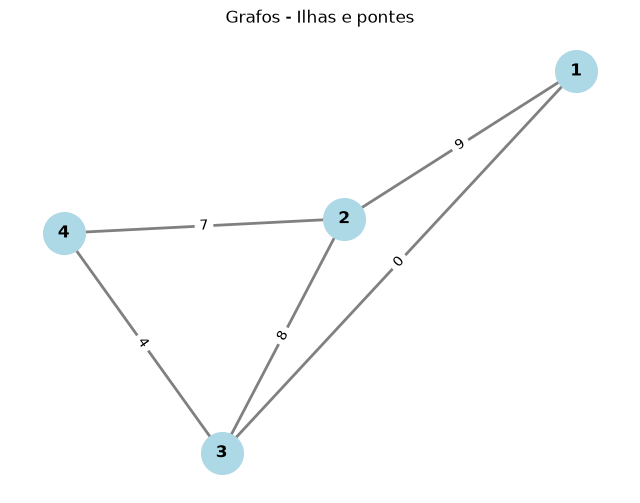

In [13]:
posicoes = nx.spring_layout(grafo, seed=42)

plt.figure(figsize=(8, 6))
nx.draw_networkx(
    grafo,
    posicoes,
    with_labels=True,
    node_color="lightblue",
    node_size=900,
    edge_color="gray",
    width=2,
    font_weight="bold",
)

pesos = nx.get_edge_attributes(grafo, "weight")
nx.draw_networkx_edge_labels(grafo, posicoes, edge_labels=pesos)

plt.title("Grafos - Ilhas e pontes")
plt.axis("off")
plt.show()

In [1]:
arvore_maxima = nx.maximum_spanning_tree(
    grafo,
    weight="weight",
    algorithm="kruskal",
)

print(list(arvore_maxima.edges(data="weight")))

NameError: name 'nx' is not defined

In [ ]:
inicio, fim = casos[0]["sedes"][0]

caminho = nx.shortest_path(
    arvore_maxima,
    source=inicio,
    target=fim,
)

print(caminho)